## 1. Introduction

Amazon hosts thousands of electronics products, each with different prices, discounts, ratings, and sales indicators. 
Understanding how these factors vary across products and categories can help optimize pricing, discount strategies, and product positioning.

In this notebook, I perform exploratory data analysis (EDA) on the 
**"Amazon Products Sales Dataset 42K+ Items – 2025"**, which contains over 42,000 
Amazon electronics products scraped from the marketplace, including features like product name, category, price, discounted price, discount percentage, ratings, review counts, and more.

**Objectives:**
- Understand the structure and quality of the raw dataset.
- Clean and preprocess the uncleaned CSV into an analysis‑ready dataset.
- Analyze pricing and discount distributions across products.
- Explore ratings and review patterns to understand product popularity.
- Identify top categories and sub‑categories by price, discount, and rating.


## 2. Setup & Data Loading

In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
df_raw= pd.read_csv('amazon_products_sales_data_uncleaned.csv')

df_raw.head()

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6 out of 5 stars,375,300+ bought in past month,89.68,basic variant price: 2.4GHz,$159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3 out of 5 stars,"2,457",6K+ bought in past month,9.99,basic variant price: nan,$15.99,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6 out of 5 stars,"3,044",2K+ bought in past month,314.00,basic variant price: nan,$349.00,No Badge,Sponsored,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6 out of 5 stars,"35,882",10K+ bought in past month,NaN,basic variant price: $162.24,No Discount,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8 out of 5 stars,"28,988",10K+ bought in past month,NaN,basic variant price: $72.74,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29


## 3. Data understanding

#### 3.1 Dataset Overview

- **Rows:** `df_raw.shape[0]` (number of products)
- **Columns:** `df_raw.shape[1]`
- All columns and data types are listed above.
- 
Here we look for object columns that should be numeric (prices, ratings, percentages) 
and any columns with many missing values.

In [2]:
df_raw.shape

(42675, 16)

##### 3.1 Analysis

We observe there are total of 4,265 rows and 16 columns present in `df_raw`

#### 3.2 Sample rows and missing values

This sample shows how raw values are stored (e.g., currency symbols in prices, 
text in rating columns, long product descriptions). The missing‑value table 
helps decide which columns to clean, impute, or drop.

In [3]:
df_raw.sample(5, random_state=42)

,title,rating,number_of_reviews,bought_in_last_month,current/discounted_price,price_on_variant,listed_price,is_best_seller,is_sponsored,is_couponed,buy_box_availability,delivery_details,sustainability_badges,image_url,product_url,collected_at
12457,"Bose QuietComfort Earbuds II, Wireless, Blueto...",3.9 out of 5 stars,"15,351",100+ bought in past month,NaN,basic variant price: nan,No Discount,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/51RM+UZFwO...,/Bose-QuietComfort-Cancelling-Personalized-Can...,2025-08-24 22:11:19
354,Fujifilm QuickSnap Flash 400 One Time Use 35mm...,4.6 out of 5 stars,380,5K+ bought in past month,68.88,basic variant price: nan,$76.89,Amazon's,Organic,No Coupon,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/81kfPqxQL5...,/Fujifilm-QuickSnap-Flash-Disposable-Camera/dp...,2025-08-21 11:17:53
11680,Renata Watch Battery 321 0%Hg Mercury Free X 3,4.6 out of 5 stars,"1,533",600+ bought in past month,6.95,basic variant price: 3 Count (Pack of 1),No Discount,No Badge,Organic,No Coupon,Add to cart,"Delivery Tue, Sep 2",NaN,https://m.media-amazon.com/images/I/61uoafSNsv...,NaN,2025-08-24 22:05:10
36143,"Apple Mid 2015 iPad Mini 4 7.9-inch, Wi-Fi, 64...",3.9 out of 5 stars,483,200+ bought in past month,109.00,basic variant price: nan,No Discount,No Badge,Organic,No Coupon,NaN,"FREE delivery Thu, Sep 4Or fastest delivery To...",NaN,https://m.media-amazon.com/images/I/61MRDo+gSb...,/Apple-iPad-Wi-Fi-7-9-Inch-Tablet/dp/B01N8SQV1...,2025-08-30 00:17:55
34102,Spigen Slim Armor CS Designed for iPhone 13 Pr...,4.3 out of 5 stars,"2,685",400+ bought in past month,17.99,basic variant price: nan,$39.99,No Badge,Organic,No Coupon,Add to cart,"FREE delivery Wed, Sep 3 on $35 of items shipp...",NaN,https://m.media-amazon.com/images/I/51qjmN+SM7...,/Spigen-Slim-Armor-Designed-iPhone/dp/B096HBY1...,2025-08-29 11:37:22


In [4]:
df_raw.isna().sum().sort_values(ascending=False)

sustainability_badges       39267
buy_box_availability        14653
current/discounted_price    11749
delivery_details            11720
bought_in_last_month         3217
product_url                  2069
rating                       1024
number_of_reviews            1024
title                           0
price_on_variant                0
listed_price                    0
is_best_seller                  0
is_sponsored                    0
is_couponed                     0
image_url                       0
collected_at                    0
dtype: int64

## 4. Data cleaning & feature engineering

#### 4.1 Copy raw → working DataFrame

In [5]:
df= df_raw.copy()

#### 4.2 Formating Columns

In [6]:
# Reaming the columns for better usecase
rename_map = {
    "number_of_reviews": "num_reviews",
    "bought_in_last_month": "bought_last_month",
    "current/discounted_price": "current_discounted_price",
    "price_on_variant": "base_variant_price",
    "is_couponed": "has_coupon",
    "buy_box_availability": "buy_box_available",
    # others left unchanged
}

df = df_raw.rename(columns=rename_map)
df.columns


Index(['title', 'rating', 'num_reviews', 'bought_last_month',
       'current_discounted_price', 'base_variant_price', 'listed_price',
       'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_available',
       'delivery_details', 'sustainability_badges', 'image_url', 'product_url',
       'collected_at'],
      dtype='str')

#### 4.3 Cleaning and transforming columns

In [7]:
## The 'Rating' column has texts which needs to be removed and the column type is converted to float
df['rating']=df['rating'].str.replace(' out of 5 stars','').astype(float)
df['rating']

0        4.6
1        4.3
2        4.6
3        4.6
4        4.8
        ... 
42670    5.0
42671    4.2
42672    4.3
42673    4.7
42674    4.4
Name: rating, Length: 42675, dtype: float64

In [8]:
# The "num_reviews" contained commas , which is to be removed and converted to Int
df["num_reviews"] = (
    df["num_reviews"]
    .str.replace(",", "", regex=False)
    .str.strip()
    .replace("", np.nan)
    .astype("Int64"))
df["num_reviews"]

0          375
1         2457
2         3044
3        35882
4        28988
         ...  
42670        1
42671       20
42672       57
42673     7102
42674       75
Name: num_reviews, Length: 42675, dtype: Int64

In [9]:

# This column represents the **current selling price** on Amazon, sometimes with commas and a dollar sign.  
# Stripped the `$` symbol and commas and convert it to `float`, which allows histogram and correlation analysis with other numeric features.
df["current_discounted_price"] = (
    df["current_discounted_price"]
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
    .replace("", np.nan)
    .astype(float))
df["current_discounted_price"]

0         89.68
1          9.99
2        314.00
3           NaN
4           NaN
          ...  
42670    195.99
42671     89.99
42672    899.99
42673     10.39
42674    419.99
Name: current_discounted_price, Length: 42675, dtype: float64

In [10]:
#The `base_variant_price` field includes helper text such as `"Basic variant price:"`, units like `"GHz"`, and a dollar sign.  
#Removing that text and units, then extract the first numeric pattern (e.g. from `"Basic variant price: $199.99"` to`199.99`), remove commas, and convert to `float`.  
# This gives a clean base price for the main product variant.

df["base_variant_price"] = (
        df["base_variant_price"]
        .str.replace("basic variant price:", "", case=False, regex=False)
        .str.replace("GHz", "", case=False, regex=False)
        .str.replace("$", "", regex=False)
        .str.extract(r"([\d.,]+)", expand=False)   # first numeric chunk
        .str.replace(",", "", regex=False)
        .str.strip()
        .replace("", np.nan)
        .astype(float)   )
df["base_variant_price"]

0          2.40
1           NaN
2           NaN
3        162.24
4         72.74
          ...  
42670       NaN
42671     25.00
42672     30.00
42673       NaN
42674       NaN
Name: base_variant_price, Length: 42675, dtype: float64

In [11]:
df["listed_price"].unique()

<StringArray>
[    '$159.00',      '$15.99',     '$349.00', 'No Discount',      '$19.98',
      '$14.33',      '$17.99',      '$21.89',      '$20.00',      '$48.99',
 ...
   '$2,899.00',      '$16.97',   '$2,999.99',       '$9.10',   '$1,749.99',
      '$21.39',     '$599.95',     '$139.98',     '$149.98',     '$950.43']
Length: 911, dtype: str

In [12]:
# This is the list (original) price before any discount.  
# Removing `$` and commas and convert it to `float`,
# so I can compare it to `current_discounted_price` and compute discount amounts and percentages.
df["listed_price"] = (
        df["listed_price"]
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("No Discount","", regex=False)
        .str.strip()
        .replace("", np.nan)
        .astype(float))
df["listed_price"]

0         159.00
1          15.99
2         349.00
3            NaN
4            NaN
          ...   
42670        NaN
42671        NaN
42672    1099.99
42673      15.98
42674     499.99
Name: listed_price, Length: 42675, dtype: float64

In [13]:
 # The scraped values can be `"Best seller"`, `"No Badge"`, or similar.  
 # Normalized them into `"Yes"` or `"No"` via a small mapping function:  
 #  `"Best seller"` → `Yes`, `"No Badge"` or anything else → `No`.  
 #  This makes it easy to filter and compare Best Seller products vs others.
def map_best_seller(val):
        s = str(val).strip().lower()
        if s == "best seller":
            return "Yes"
        elif s == "no badge" or s == "nan":
            return "No"
        else:
            return "No"
df["is_best_seller"] = df["is_best_seller"].apply(map_best_seller)

s = df["has_coupon"].astype(str).str.strip()

# is_discounted column
df["is_discounted"] = np.where(
        s.str.contains("save", case=False) & s.str.contains("coupon", case=False),
        "Yes",
        "No")

# coupon_value column
# extract number before % and divide by 100
coupon_pct = (
        s.str.extract(r"(\d+)\s*%", expand=False)
         .astype(float)
    )
df["coupon_value"] = coupon_pct / 100.0
df.drop(columns=['has_coupon'], inplace=True)
df[[ "is_discounted", "coupon_value"]]

,is_discounted,coupon_value
0,Yes,0.15
1,No,NaN
2,No,NaN
3,No,NaN
4,No,NaN
...,...,...
42670,No,NaN
42671,Yes,NaN
42672,No,NaN
42673,No,NaN


In [14]:
# Using the `title` text,Classifying each product into one of three broad categories:  
#   - `"Laptop"` if the title mentions **laptop** terms such as `"laptop"`, `"macbook"`, `"notebook pc"`, or `"chromebook"`.  
#   - `"Phone"` if the title clearly refers to a **phone** such as `"iPhone"`, `"smartphone"`, `"mobile phone"`, `"Galaxy S"`, or `"Pixel phone"`.  
#   - `"Other Electronics"` for all remaining titles (mics, earbuds, cables, accessories, etc.).  
#   This simple grouping helps compare laptops vs phones vs other electronics segments in the dataset.

def simple_product_category(title: str) -> str:
    t = str(title).lower()

    # Laptop keywords
    if any(k in t for k in [
        "laptop",
        "macbook",
        "notebook pc",
        "chromebook"
    ]):
        return "Laptop"

    # Phone keywords
    if any(k in t for k in [
        "iphone",
        "android phone",
        "smartphone",
        "mobile phone",
        "cell phone",
        "galaxy s",
        "pixel phone"
    ]):
        return "Phone"

    # Fallback
    return "Other Electronics"
df["product_category"] = df["title"].apply(simple_product_category)
df["product_category"].value_counts()


product_category
Other Electronics    36240
Laptop                3930
Phone                 2505
Name: count, dtype: int64

In [15]:
# The original field contains strings like `"123+ bought in past month"` or `"6k bought in past month"`.  
#   Removing the trailing text `"+ bought in past month"`, then:  
#   - Extract the numeric part plus an optional `k` suffix.  
#   - Convert `"6k"` to `6000` (multiply by 1,000), and plain numbers like `"123"` to `123`.  
#   - Store the result as a nullable integer (`Int64`).  
#   This gives a clean numeric estimate of recent purchase volume for each product, useful as a demand signal.

df["bought_last_month"] = (
    df["bought_last_month"]
    .astype(str)
    .str.replace("+ bought in past month", "", regex=False)
    .str.strip()
    .pipe(lambda s: s.str.extract(r"(\d+\.?\d*)\s*([kK]?)", expand=True))
    .pipe(lambda df_extracted: (
        (df_extracted[0].replace("", pd.NA).astype(float) *
         df_extracted[1].str.lower().map({"k": 1000}).fillna(1))
        .round()
        .astype("Int64")
    ))
)
df["bought_last_month"]

0          300
1         6000
2         2000
3        10000
4        10000
         ...  
42670      100
42671      200
42672       50
42673      500
42674       50
Name: bought_last_month, Length: 42675, dtype: Int64

In [16]:
df.head()

,title,rating,num_reviews,bought_last_month,current_discounted_price,base_variant_price,listed_price,is_best_seller,is_sponsored,buy_box_available,delivery_details,sustainability_badges,image_url,product_url,collected_at,is_discounted,coupon_value,product_category
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375,300,89.68,2.40,159.00,No,Sponsored,Add to cart,"Delivery Mon, Sep 1",Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,Yes,0.15,Phone
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457,6000,9.99,NaN,15.99,No,Sponsored,Add to cart,"Delivery Fri, Aug 29",NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,No,NaN,Laptop
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044,2000,314.00,NaN,349.00,No,Sponsored,Add to cart,"Delivery Mon, Sep 1",NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,/sspa/click?ie=UTF8&spc=MTo4NzEzNDY2NTQ5NDYxND...,2025-08-21 11:14:29,No,NaN,Phone
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882,10000,NaN,162.24,NaN,Yes,Organic,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,/Apple-Cancellation-Transparency-Personalized-...,2025-08-21 11:14:29,No,NaN,Other Electronics
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988,10000,NaN,72.74,NaN,No,Organic,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,/Apple-MX542LL-A-AirTag-Pack/dp/B0D54JZTHY/ref...,2025-08-21 11:14:29,No,NaN,Phone


## 5. Data Structure and Quality

In [17]:
df.info()
df.describe(include="all")
df.isna().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     42675 non-null  str    
 1   rating                    41651 non-null  float64
 2   num_reviews               41651 non-null  Int64  
 3   bought_last_month         32233 non-null  Int64  
 4   current_discounted_price  30926 non-null  float64
 5   base_variant_price        21298 non-null  float64
 6   listed_price              12311 non-null  float64
 7   is_best_seller            42675 non-null  str    
 8   is_sponsored              42675 non-null  str    
 9   buy_box_available         28022 non-null  str    
 10  delivery_details          30955 non-null  str    
 11  sustainability_badges     3408 non-null   str    
 12  image_url                 42675 non-null  str    
 13  product_url               40606 non-null  str    
 14  collected_at     

coupon_value                41614
sustainability_badges       39267
listed_price                30364
base_variant_price          21377
buy_box_available           14653
current_discounted_price    11749
delivery_details            11720
bought_last_month           10442
product_url                  2069
num_reviews                  1024
rating                       1024
is_discounted                   0
collected_at                    0
title                           0
image_url                       0
is_sponsored                    0
is_best_seller                  0
product_category                0
dtype: int64

In [18]:
# Negative or zero prices
df[df["current_discounted_price"] <= 0].head()
df[df["listed_price"] <= 0].head()

,title,rating,num_reviews,bought_last_month,current_discounted_price,base_variant_price,listed_price,is_best_seller,is_sponsored,buy_box_available,delivery_details,sustainability_badges,image_url,product_url,collected_at,is_discounted,coupon_value,product_category


In [19]:
# Malformed ratings (after cleaning, anything out of expected range)
df[(df["rating"] < 1) | (df["rating"] > 5)].head()

,title,rating,num_reviews,bought_last_month,current_discounted_price,base_variant_price,listed_price,is_best_seller,is_sponsored,buy_box_available,delivery_details,sustainability_badges,image_url,product_url,collected_at,is_discounted,coupon_value,product_category


In [20]:

# Junk text in numeric fields should already be NaN; verify distributions
df[["rating", "num_reviews", "bought_last_month",
    "current_discounted_price", "base_variant_price",
    "listed_price"]].describe()

,rating,num_reviews,bought_last_month,current_discounted_price,base_variant_price,listed_price
count,41651.000000,41651.0,32233.0,30926.000000,21298.000000,12311.000000
mean,4.399431,3087.106,1291.676729,212.607587,220.796366,214.461505
std,0.386997,13030.460133,6311.724966,389.888111,496.943704,443.524770
min,1.000000,1.0,1.0,2.490000,1.000000,4.950000
25%,4.200000,82.0,100.0,25.990000,24.120000,27.330000
50%,4.500000,343.0,200.0,77.000000,72.000000,59.990000
75%,4.700000,1886.0,400.0,197.950000,205.490000,185.000000
max,5.000000,865598.0,100000.0,4699.000000,5449.000000,5399.000000


In [21]:
# Unique counts
df["title"].nunique()

8808

#### Analysis

##### 1.1 Overall shape and schema

The cleaned dataset contains **42,675 product rows** and **18 columns**, with a mix of numeric and categorical fields:

- Numeric: `rating`, `num_reviews`, `bought_last_month`, `current_discounted_price`, `base_variant_price`, `listed_price`, `coupon_value`.
- Categorical / text: `title`, `is_best_seller`, `is_sponsored`, `buy_box_available`, `delivery_details`, `sustainability_badges`, `image_url`, `product_url`, `collected_at`, `is_discounted`, `product_category`.

This schema is appropriate for answering questions about pricing, discounts, ratings, popularity, and simple product segmentation (Laptop / Phone / Other Electronics).

##### 1.2 Missing data patterns

Missing values are not uniform across columns:

- **Core signal columns** (`rating`, `num_reviews`, `bought_last_month`, `current_discounted_price`) are available for the majority of products, making them reliable for global EDA.
- **Price reference fields** (`base_variant_price`, `listed_price`) and `buy_box_available` have substantial gaps, so any analysis involving original price or buy box status will be performed on subsets.
- **Coupon and sustainability information** is very sparse: `coupon_value` is present for only a small fraction of rows and `sustainability_badges` is non‑null for a few thousand products. These will be used only in targeted, exploratory views rather than dataset‑wide metrics.

Overall, the dataset is rich enough for robust analysis of ratings, demand (`bought_last_month`), and current prices, with more limited coverage for original list prices, coupons, and sustainability attributes.

##### 1.3 Numeric distributions and data quality

For the main numeric columns (`rating`, `num_reviews`, `bought_last_month`, `current_discounted_price`, `base_variant_price`, `listed_price`), the summary statistics indicate:

- **Ratings**  
  - Mean ≈ 4.4, median ≈ 4.5, interquartile range roughly 4.2–4.7.  
  - Minimum is 1.0 and maximum is 5.0, with no values outside the valid rating scale.  
  - This confirms that the “_out of 5 stars_” parsing worked correctly, and it also shows strong **rating inflation**: most products are highly rated, which is typical for Amazon electronics datasets.

- **Number of reviews (`num_reviews`)**  
  - Median ≈ 343 and 75th percentile ≈ 1,886, but the maximum goes up to ~865,000.  
  - The very large standard deviation compared to the mean confirms an extreme **right‑skew**: many products have modest review counts, while a small set of “hero” items have extremely high engagement.  
  - This makes `num_reviews` a powerful signal for identifying best‑selling or highly visible products.

- **Recent demand (`bought_last_month`)**  
  - Median ≈ 200 and 75th percentile ≈ 400, with a maximum of 100,000.  
  - As with reviews, the distribution is highly skewed: most products sell relatively few units in the last month, but a minority exhibit very high recent purchase volumes.

- **Prices (`current_discounted_price`, `base_variant_price`, `listed_price`)**  
  - All price columns have strictly positive values after cleaning; no negative or zero prices remain, indicating that currency and text stripping was successful.  
  - Medians are in the **60–80** range, with upper quartiles around **180–200** and long tails reaching into the low thousands.  
  - This is consistent with a catalog spanning low‑cost accessories (cables, small peripherals) to higher‑end electronics (laptops, premium audio, etc.).

These distributions confirm that the numeric fields are clean and behave as expected for an e‑commerce electronics dataset: heavy skew in engagement metrics, inflated ratings, and broad price ranges.



## 6. Category and sub-category profile

In [22]:
# Product category distribution
df["product_category"].value_counts()

product_category
Other Electronics    36240
Laptop                3930
Phone                 2505
Name: count, dtype: int64

In [23]:
cat_profile = (
    df.groupby("product_category")
      .agg(
          n_products=("title", "count"),
          avg_rating=("rating", "mean"),
          median_rating=("rating", "median"),
          avg_reviews=("num_reviews", "mean"),
          median_reviews=("num_reviews", "median")
      )
      .sort_values("n_products", ascending=False)
)
cat_profile

,n_products,avg_rating,median_rating,avg_reviews,median_reviews
product_category,,,,,
Other Electronics,36240,4.403190,4.5,3092.031284,335.0
Laptop,3930,4.427042,4.5,1750.273932,421.5
Phone,2505,4.305431,4.4,4991.662141,1468.0


##### Analysis  


The dataset has three engineered categories:

- **Other Electronics:** 36,240 products  
- **Laptop:** 3,930 products  
- **Phone:** 2,505 products  

So the catalog is strongly skewed toward **Other Electronics**, with Laptops and Phones forming smaller but still meaningful segments. This means overall statistics are dominated by accessories and mixed electronics, so I also look at metrics per category rather than only in aggregate.

**Category Profile – Key Takeaways**

- **Catalog mix:** Other Electronics dominates the catalog (36,240 products), with Laptops (3,930) and Phones (2,505) as smaller segments.

- **Customer satisfaction:** Average ratings are high and similar for all categories (around **4.3–4.4**), with Laptops having the highest average rating (~4.43) and Phones slightly lower (~4.31), but still strong.

- **Engagement / demand:** Phones stand out for **very high review volumes** (median ≈ 1,468 reviews per product), compared with Laptops (~422) and Other Electronics (~335).  
  This suggests phone products tend to attract more customer engagement and likely higher demand, even though their average rating is a bit lower than Laptops.

## 7. Pricing and Discount Patterns 

In [24]:
# Compute discount fields where both prices are available
mask = df["listed_price"].notna() & df["current_discounted_price"].notna()

df.loc[mask, "discount_amount"] = (
    df.loc[mask, "listed_price"] - df.loc[mask, "current_discounted_price"]
)

df.loc[mask, "discount_percentage"] = (
    df.loc[mask, "discount_amount"] / df.loc[mask, "listed_price"] * 100
)

# Ignore weird cases where listed_price <= 0
df.loc[df["listed_price"] <= 0, "discount_percentage"] = np.nan

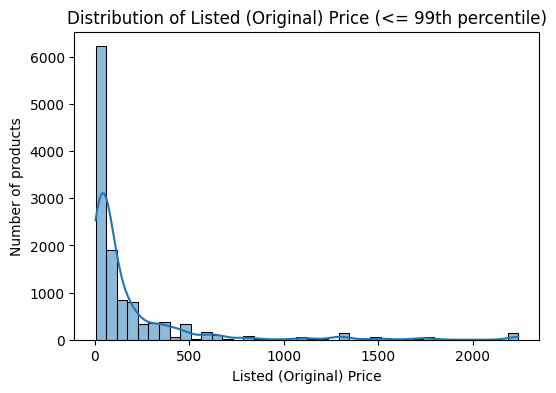

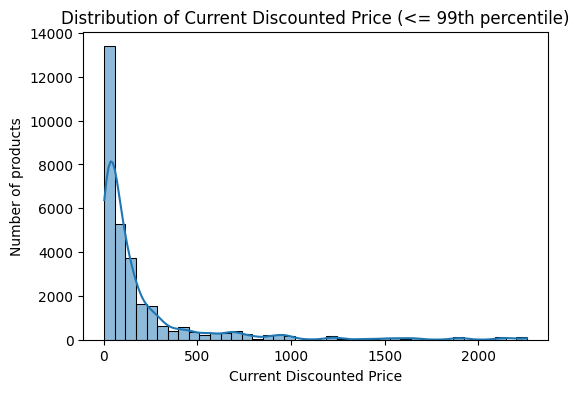

product_category
Other Electronics    79.99
Laptop               59.99
Phone                35.96
Name: current_discounted_price, dtype: float64

In [25]:
# Overall listed vs discounted price (capped at 99th percentile)
for col, title in [
    ("listed_price", "Listed (Original) Price"),
    ("current_discounted_price", "Current Discounted Price")
]:
    plt.figure(figsize=(6,4))
    sns.histplot(
        df.loc[df[col] <= df[col].quantile(0.99), col],
        bins=40, kde=True
    )
    plt.title(f"Distribution of {title} (<= 99th percentile)")
    plt.xlabel(title)
    plt.ylabel("Number of products")
    plt.show()
    
# Median current price by category
price_by_cat = (
    df.groupby("product_category")["current_discounted_price"]
      .median()
      .sort_values(ascending=False)
)
price_by_cat

##### Anaalysis

- The **current discounted price** distribution is strongly **right‑skewed**: most products are clustered below ~200, with a long tail of higher‑priced items extending beyond 2,000. This matches a typical electronics catalog where low‑cost accessories dominate, but a smaller number of premium devices pull the upper tail.

- By category, the **median current price** is:
  - Other Electronics: **≈ 79.99**
  - Laptop: **≈ 59.99**
  - Phone: **≈ 35.96**

  This indicates that:
  - **Other Electronics** includes many mid‑priced items as well as premium accessories, driving its median higher.
  - **Laptops** have a lower median here because the category likely mixes cheaper accessories labeled as “Laptop” (e.g. sleeves, stands) along with actual devices, pulling the middle down.
  - **Phones** sit at the lowest median price, suggesting a large number of budget / mid‑range phone products or phone accessories in that bucket.

Overall, prices are concentrated in a low–mid range with a few very expensive products, and there are clear differences in typical price levels across the three categories.

## 8. Ratings & Popularity

#### 8.1 Distributions of ratings and review counts

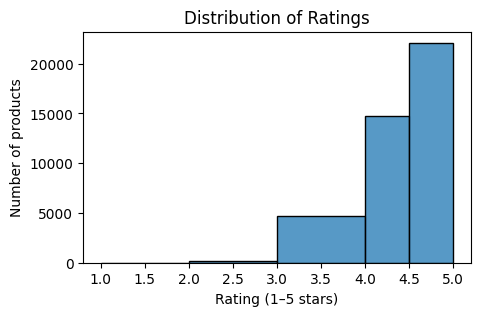

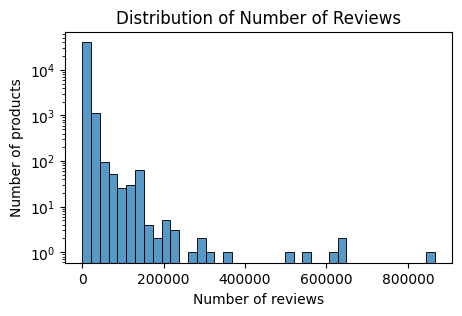

(np.float64(0.035317279297015676),
 np.int64(5591),
 np.float64(0.10026169839859787))

In [ ]:
# 8.1.1 Ratings distribution
plt.figure(figsize=(5, 3))
sns.histplot(df["rating"].dropna(), bins=[1, 2, 3, 4, 4.5, 5], kde=False)
plt.title("Distribution of Ratings")
plt.xlabel("Rating (1–5 stars)")
plt.ylabel("Number of products")
plt.show()

# 8.1.2 Number of reviews (raw + log-scaled y)
plt.figure(figsize=(5, 3))
sns.histplot(df["num_reviews"].dropna(), bins=40)
plt.title("Distribution of Number of Reviews")
plt.xlabel("Number of reviews")
plt.ylabel("Number of products")
plt.yscale("log")  # reveals long tail
plt.show()

# Fractions with almost no reviews vs very high engagement
low_review_thresh = 5
high_review_thresh = df["num_reviews"].quantile(0.9)  # top 10% by reviews

share_low = (df["num_reviews"] <= low_review_thresh).mean()
share_high = (df["num_reviews"] >= high_review_thresh).mean()

share_low, high_review_thresh, share_high

##### Analysis

- Ratings are heavily inflated: almost all products fall between 4 and 5 stars, with very few low‑rated items.

- About 3.5% of products have ≤ 5 reviews, meaning only a small slice of the catalog is almost unrated.

- The top 10% of products (those with ≥ 5,591 reviews) show extremely high engagement, forming the long tail in the review‑count distribution.

#### 8.2 Category-level ratings and engagement

In [28]:
ratings_by_cat = (
    df.groupby("product_category")
      .agg(
          n_products=("title", "count"),
          avg_rating=("rating", "mean"),
          median_rating=("rating", "median"),
          median_reviews=("num_reviews", "median")
      )
      .sort_values("n_products", ascending=False)
)
ratings_by_cat

,n_products,avg_rating,median_rating,median_reviews
product_category,,,,
Other Electronics,36240,4.403190,4.5,335.0
Laptop,3930,4.427042,4.5,421.5
Phone,2505,4.305431,4.4,1468.0


##### Analysis

we see that:

- All three categories (**Laptop, Phone, Other Electronics**) have **similarly high median ratings** (around **4.4–4.5**), so there is no obvious category where customers are consistently unhappy.

- **Phones** stand out for **much higher median review counts** than Laptops and Other Electronics, suggesting that phone products draw more customer engagement and likely higher demand on average.

## 9. Relationships: Price, Discount & Ratings

#### 9.1 Price vs Rating

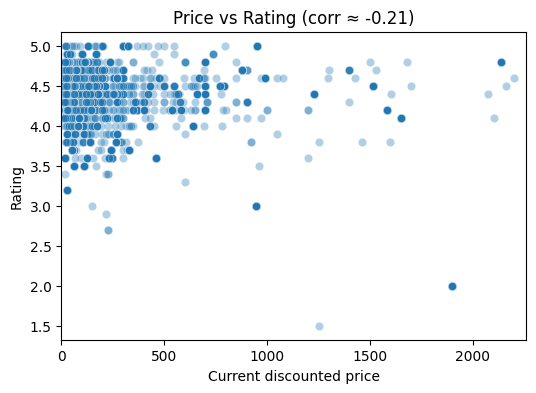

In [31]:
# Sample to keep plots light
sample = df[["current_discounted_price", "rating"]].dropna().sample(
    min(5000, df[["current_discounted_price", "rating"]].dropna().shape[0]),
    random_state=42
)

# Correlation
corr_price_rating = df[["current_discounted_price", "rating"]].dropna().corr().iloc[0, 1]

plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=sample,
    x="current_discounted_price",
    y="rating",
    alpha=0.35
)
plt.xlim(0, df["current_discounted_price"].quantile(0.99))
plt.title(f"Price vs Rating (corr ≈ {corr_price_rating:.2f})")
plt.xlabel("Current discounted price")
plt.ylabel("Rating")
plt.show()

##### Analysis

- Ratings stay mostly between **3.5 and 5 stars** across the entire price range, and the correlation of about **−0.21** is weakly negative, not strong.  
- This means **higher‑priced products do not consistently receive better ratings**; in fact, if anything, very expensive items sometimes attract slightly lower scores.  
- Overall, perceived quality (rating) is largely **independent of price** in this dataset – customers can find well‑rated and poorly rated products at almost every price point.

#### 9.2 Discount vs rating and engagement

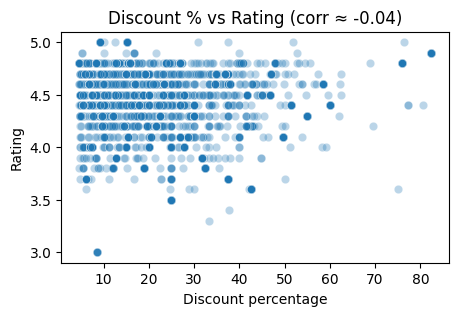

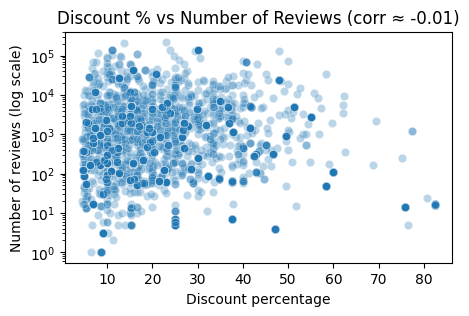

In [33]:

disc_df = df[["discount_percentage", "rating", "num_reviews"]].dropna()
disc_df = disc_df[disc_df["discount_percentage"].between(0, 100)]

# Correlations
corr_disc_rating = disc_df[["discount_percentage", "rating"]].corr().iloc[0, 1]
corr_disc_reviews = disc_df[["discount_percentage", "num_reviews"]].corr().iloc[0, 1]

plt.figure(figsize=(5, 3))
sns.scatterplot(
    data=disc_df.sample(min(5000, len(disc_df)), random_state=42),
    x="discount_percentage",
    y="rating",
    alpha=0.3
)
plt.title(f"Discount % vs Rating (corr ≈ {corr_disc_rating:.2f})")
plt.xlabel("Discount percentage")
plt.ylabel("Rating")
plt.show()

plt.figure(figsize=(5, 3))
sns.scatterplot(
    data=disc_df.sample(min(5000, len(disc_df)), random_state=42),
    x="discount_percentage",
    y="num_reviews",
    alpha=0.3
)
plt.yscale("log")
plt.title(f"Discount % vs Number of Reviews (corr ≈ {corr_disc_reviews:.2f})")
plt.xlabel("Discount percentage")
plt.ylabel("Number of reviews (log scale)")
plt.show()

##### Analysis

- **Discount % vs Rating (corr ≈ −0.04):** Ratings remain tightly clustered between 4 and 5 stars across all discount levels, and the correlation is almost zero. Deeper discounts do **not** systematically correspond to worse (or better) ratings – discounted items are not clearly lower quality.

- **Discount % vs Number of Reviews (corr ≈ −0.01):** The cloud of points and near‑zero correlation show that products with very high or very low discounts can both have few reviews or huge numbers of reviews. In other words, **discount depth alone does not drive engagement**; highly reviewed items appear at many discount levels.

- Overall, discounts in this dataset look more like a **tactical pricing lever** than a strong signal of product quality or demand: good and popular products can be found at both low and high discount percentages.

#### 9.3 Value for Price Zone

In [34]:
# Define price bands (adjust edges if you like)
price_bins = pd.cut(
    df["current_discounted_price"],
    bins=[0, 25, 50, 100, 200, 500, np.inf],
    labels=["0–25", "25–50", "50–100", "100–200", "200–500", "500+"]
)

sweet_spot = (
    df.assign(price_band=price_bins)
      .groupby("price_band")
      .agg(
          avg_rating=("rating", "mean"),
          med_rating=("rating", "median"),
          avg_reviews=("num_reviews", "mean"),
          med_reviews=("num_reviews", "median"),
          n_products=("title", "count")
      )
)
sweet_spot

,avg_rating,med_rating,avg_reviews,med_reviews,n_products
price_band,,,,,
0–25,4.603904,4.6,7335.996322,1671.0,7073
25–50,4.466649,4.6,3403.602048,686.0,5760
50–100,4.375652,4.4,2576.78726,340.0,5113
100–200,4.374520,4.4,1564.253715,280.0,5589
200–500,4.288071,4.4,732.71999,191.0,4017
500+,4.267645,4.4,608.678685,72.0,3374


##### Analysis

- **Low‑price band (0–25):** Highest average rating (~4.60) and by far the strongest engagement (median ≈ 1,671 reviews), suggesting many cheap but well‑liked, high‑volume products.

- **Mid‑price bands (25–100):** Ratings remain high (median 4.4–4.6), but median reviews drop from ~686 (25–50) to ~340 (50–100). These look like solid **value‑for‑money zones**: still affordable, well reviewed, and with decent engagement.

- **High‑price bands (200+):** Ratings are only slightly lower on average (~4.29–4.27), but median reviews fall steadily (from ~191 down to ~72). Expensive products are fewer and tend to attract **less frequent reviewing**, so the clearest “sweet spot” for both good ratings and strong engagement lies roughly between **0–100**, especially the **0–50** range.

## 10. Product-level Outliers & Hero Items

#### 10.1 Hero products – highest review counts

In [35]:
# Columns to inspect
hero_cols = [
    "title", "product_category",
    "current_discounted_price", "listed_price", "discount_percentage",
    "rating", "num_reviews", "bought_last_month",
    "is_best_seller", "is_discounted"
]

# Overall top 10 by number of reviews
top_overall = (
    df.sort_values("num_reviews", ascending=False)
      .loc[:, hero_cols]
      .head(10)
)
top_overall

# Top 5 per category by number of reviews
top_by_cat = (
    df.sort_values("num_reviews", ascending=False)
      .groupby("product_category")
      .head(5)
      .loc[:, hero_cols]
)
top_by_cat

,title,product_category,current_discounted_price,listed_price,discount_percentage,rating,num_reviews,bought_last_month,is_best_seller,is_discounted
10,Amazon Basics 48-Pack AA Alkaline High-Perform...,Other Electronics,14.99,NaN,NaN,4.7,865598,100000,Yes,No
8565,SanDisk 32GB Ultra microSDHC UHS-I Memory Card...,Other Electronics,NaN,NaN,NaN,4.7,645418,1000,No,No
8909,[Older Version] SanDisk 32GB 2-Pack Ultra Micr...,Other Electronics,12.46,15.99,22.076298,4.7,645416,400,No,No
17,Amazon Basics AAA Alkaline High-Performance Ba...,Other Electronics,14.49,NaN,NaN,4.7,625776,100000,Yes,No
695,"Amazon Basics HDMI Cable, 3ft, 4K@60Hz, High-S...",Other Electronics,5.99,NaN,NaN,4.7,553927,10000,No,No
4014,Panasonic ErgoFit Wired Earbuds With Microphon...,Laptop,18.90,NaN,NaN,4.3,141679,1000,No,No
10709,iOttie Easy One Touch Signature Dashboard & Wi...,Phone,24.95,NaN,NaN,4.4,139943,10000,No,No
10628,iOttie Easy One Touch Advanced Universal Car M...,Phone,18.84,26.95,30.092764,4.4,139943,5000,No,No
11846,iOttie Easy One Touch Advanced Universal Car M...,Phone,18.84,26.95,30.092764,4.4,139943,5000,No,No
10199,iOttie Easy One Touch Advanced Universal Car M...,Phone,18.84,26.95,30.092764,4.4,139943,5000,No,No


##### Analysis


- The top products by review count are mostly **Amazon Basics essentials** (AA/AAA batteries, HDMI cable, laptop sleeve) and **SanDisk microSD cards**, all with ratings around **4.7–4.8** and **tens to hundreds of thousands of reviews**. These are clear long‑term best‑sellers: cheap, reliable, and bought repeatedly.

- Several **phone accessories** (iOttie car mounts / wireless chargers) also appear as hero items, with ~140k reviews and strong ratings (~4.4). Their moderate prices and high utility make them high‑volume products in the Phone segment.

- Many of these hero items show **very high `bought_last_month` values** (thousands to 100k+ units), confirming that they are not only historically popular but also still selling heavily. Together, they illustrate a pattern of “everyday utility + affordable price + strong rating” driving sustained bestseller status across categories.

#### 10.2 Low rating but high review count

In [36]:
# Threshold for "high reviews" – top 10% by num_reviews
high_review_thresh = df["num_reviews"].quantile(0.9)

low_rating_high_reviews = (
    df[
        (df["rating"] <= 3.5) &
        (df["num_reviews"] >= high_review_thresh)
    ]
    .sort_values("num_reviews", ascending=False)
    .loc[:, hero_cols]
    .head(10)
)
low_rating_high_reviews

,title,product_category,current_discounted_price,listed_price,discount_percentage,rating,num_reviews,bought_last_month,is_best_seller,is_discounted


##### Analysis

- There are no such products with rating lower than 3.5 ratings and highest reviews

#### 10.3 Extreme prices and discounts within categories

In [39]:
# Recompute z-scores by category (idempotent)
df["cat_mean_price"] = (
    df.groupby("product_category")["current_discounted_price"]
      .transform(lambda x: (x - x.mean()) / x.std(ddof=0))
)

df["cat_mean_discount"] = (
    df.groupby("product_category")["discount_percentage"]
      .transform(lambda x: (x - x.mean()) / x.std(ddof=0)).round(2)
)

# Very expensive / very cheap relative to category (|z| > 3)
price_outliers = (
    df[df["cat_mean_price"].abs() > 3]
    .sort_values("cat_mean_price", ascending=False)
    .loc[:, hero_cols + ["cat_mean_price"]]
    .head(10)
)
price_outliers

# Extremely high or low discounts relative to category
disc_outliers = (
    df[df["cat_mean_discount"].abs() > 3]
    .sort_values("cat_mean_discount", ascending=False)
    .loc[:, hero_cols + ["cat_mean_discount"]]
    .head(10)
)
disc_outliers

,title,product_category,current_discounted_price,listed_price,discount_percentage,rating,num_reviews,bought_last_month,is_best_seller,is_discounted,cat_mean_discount
7988,Samsung Electronics Galaxy Watch 4 Classic 42m...,Other Electronics,44.99,308.48,85.415586,4.2,1219,200,No,No,4.76
9633,Samsung Galaxy Watch 4 Classic 42mm Smartwatch...,Other Electronics,44.99,263.50,82.925996,4.2,1600,200,No,No,4.58
5389,"Monster Shock Portable Bluetooth Speaker,30W L...",Other Electronics,34.99,199.99,82.504125,4.2,167,<NA>,No,No,4.55
6409,Monster Clarity 101Plus AirLinks Wireless Earb...,Other Electronics,29.99,171.99,82.562940,4.1,1870,500,No,No,4.55
26924,"Monster Open Ear AC360, Wireless Bluetooth Rot...",Other Electronics,29.99,169.99,82.357786,4.9,16,<NA>,No,No,4.53
29598,"Monster Open Ear AC360, Wireless Bluetooth Rot...",Other Electronics,29.99,169.99,82.357786,4.9,16,<NA>,No,No,4.53
29770,"Monster Open Ear AC360, Wireless Bluetooth Rot...",Other Electronics,29.99,169.99,82.357786,4.9,16,<NA>,No,No,4.53
30353,"Monster Open Ear AC360, Wireless Bluetooth Rot...",Other Electronics,29.99,169.99,82.357786,4.9,16,<NA>,No,No,4.53
37537,"Monster Open Ear AC360, Wireless Bluetooth Rot...",Other Electronics,29.99,169.99,82.357786,4.9,17,<NA>,No,No,4.53
30663,"Monster Open Ear AC360, Wireless Bluetooth Rot...",Other Electronics,29.99,169.99,82.357786,4.9,16,<NA>,No,No,4.53


##### Analysis


- These products sit around **82–85% off** while the average discount in their category (“Other Electronics”) is only about **4–5%**, making them clear **high‑discount outliers**.

- Despite such aggressive markdowns, most of them still hold **strong ratings (≈ 4.1–4.9)** and, in the case of the Samsung Galaxy Watch 4 Classic and Monster earbuds, **meaningful review counts**, so there is no obvious sign that quality is being sacrificed for discounting.

- For some variants with only a handful of reviews (e.g., 16–17 ratings), the combination of extremely high discount and very low engagement suggests **newer or niche listings** that are being pushed with heavy promotions to gain traction.